In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import os
import utils.saveload as sl
import fitting_behavior.optimization.base_params_opt as bpo
from fitting_behavior.mle.mle_fit import preprocess_micedata
import utils.visualization as vis
from fitting_behavior.ppc.steps_to_goal_ppc import plot_steps_to_goal_all

/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  env = env.append(add,ignore_index=True)
/Users/sbecker/Projects/sim_nov/src/utils/tree_env.py:21: FutureWarn

# Compute number of data samples (for BIC penalty)

In [2]:
# Compute number of steps in mice data ########################################################################
def compute_size_micedata(UnrewNames=['B5','B6','B7','D3','D4','D5','D6','D7','D8','D9'],RewNames=['B1','B2','B3','B4','C1','C3','C6','C7','C8','C9']):
    AllNames    = RewNames+UnrewNames

    params = bpo.base_params_nACtree.copy()
    P = params['P']

    d = []
    len_app = 0
    len_sep = []
    for i in range(len(AllNames)):
        dir  = sl.get_rootpath() / 'ext_data' / 'Rosenberg2021'
        file = dir / f'{AllNames[i]}_data' / f'{AllNames[i]}-stateseq_UntilG.pickle'
        df_i = preprocess_micedata(dir,file,P,subID=AllNames[i],epi=0)
        d.append(df_i)
        len_app += len(df_i)
        len_sep.append(len(df_i))

    dict_len = {a:l for a,l in zip(AllNames,len_sep)}

    return len_app, dict_len

In [3]:
n_app, n_sep = compute_size_micedata()
print(f'Total number of data points (all mice): {n_app}')
n_sep

Total number of data points (all mice): 7972


{'B1': 1195,
 'B2': 11,
 'B3': 15,
 'B4': 389,
 'C1': 91,
 'C3': 85,
 'C6': 2183,
 'C7': 359,
 'C8': 39,
 'C9': 469,
 'B5': 401,
 'B6': 79,
 'B7': 1019,
 'D3': 99,
 'D4': 339,
 'D5': 347,
 'D6': 3,
 'D7': 139,
 'D8': 45,
 'D9': 665}

# Compute BIC

In [4]:
## Specify models to plot #########################################################

# Single level
model_type_list     = ['hnor']
model_label_list    = ['Single\n']
level_list          = [[[1],[2],[3],[4],[5],[6]]]
level_label_list    = [[f'l={ii[0]}' for ii in level_list[0]]]
single_run_id_list  = ['_5']

# Multiple level
model_type_list     += ['multinov-eps_hnor']
model_label_list    += ['Combined\n']
level_list          += [[[1,6],[2,6],[3,6],[4,6],[5,6]][::-1]]
level_label_list    += [[f'l={",".join(map(str, ii))}' for ii in level_list[1]]]
single_run_id_list  += ['_3']

leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
comb_type           = 'app'
run_local           = True
seed_list           = [42957]
version             = 4

## Specify plotting parameters ####################################################
extra  = 2
cnorm_b  = colors.Normalize(vmin=0, vmax=len(level_list[0])+extra) 
cmap_b = plt.cm.get_cmap('Blues') 
smap_b = cm.ScalarMappable(norm=cnorm_b, cmap=cmap_b) # blue (single distribution)
cnorm_r  = colors.Normalize(vmin=0, vmax=len(level_list[1])+extra)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm_r, cmap=cmap_r) # red (two-distribution nov.)

color_list  = [[smap_b.to_rgba(i) for i in range(extra,extra+len(level_list[0]))]]
color_list += [[smap_r.to_rgba(i) for i in range(extra,extra+len(level_list[1]))][::-1]]

model_class_list    = [['single']*len(color_list[0]), ['combined']*len(color_list[1])] 
trans_list          = [[1]*len(color_list[0]), [1]*len(color_list[1])]

## Set paths to data files ########################################################
base_path       = sl.get_rootpath()
base_path_data  = base_path / 'data' / 'mle_results' / 'fits_single-run' 
base_path_cv    = base_path / 'data' / 'mle_results' / 'fits_cv-mouseid'

# if run_local:
#     base_path_data = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/SingleRun/'
#     base_path_cv = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/MLE{version}_results/Fits/CrossValidation_mouseid'
# else:
#     base_path_data  = os.path.join(base_path, f'data/MLE{version}_results/Fits/SingleRun/')
#     base_path_cv  = os.path.join(base_path, f'data/MLE{version}_results/Fits/CrossValidation_mouseid/')

## Load fitting results + extract BIC for all models ###############################
info_fitted = []
for i, (model_type, leak_type, kernel_type, full_model, levels, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, full_models_list, level_list, single_run_id_list)):

    LL_fitted_i  = []
    PP_fitted_i  = []
    BIC_fitted_i = []
    num_params_i = []
    labels_i     = []
    for j, level_j in enumerate(levels):

        if level_j is not None and kernel_type is not None:
            level_str   = '-'.join([str(lv) for lv in level_j]) if isinstance(level_j, list) else str(level_j)
        
        # Construct path to fitted model 
        full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}{sr_id}'
        fitted_path = base_path_data / full_name / f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}'
        fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_{comb_type}.csv'

        # Load fitted model
        fitted_ij = sl.load_sim_data(fitted_path,file_data=fitted_file)

        # Extract LL / BIC 
        num_params_ij = len(fitted_ij.var_name.unique())                    # number of fitted parameters
        num_params_i.append(num_params_ij)

        penalty_ij    = num_params_ij * np.log(n_app)                       # penalty term for BIC
        PP_fitted_i.append(penalty_ij)
        
        LL_fitted_i.append(fitted_ij['mle_ll'].values[0])                   # log-likelihood
        BIC_fitted_i.append(2*fitted_ij['mle_ll'].values[0] + penalty_ij)   # BIC

        # Create label
        if level_j is not None:
            label_ij = level_label_list[i][j]
            labels_i.append(label_ij)
        else:
            labels_i.append(model_label_list[i])

    print(len(LL_fitted_i), len(model_class_list[i]), len(color_list[i]), len(trans_list[i]))
    info_fitted_i = pd.DataFrame({'full_model':         [full_model]*len(LL_fitted_i),
                                    'model_class':      model_class_list[i][:len(LL_fitted_i)+1],
                                    'model_id':         [i]*len(LL_fitted_i),
                                    'level':            levels,
                                    'LL':               LL_fitted_i,
                                    'PP':               PP_fitted_i,
                                    'BIC':              BIC_fitted_i,
                                    'color':            color_list[i][:len(LL_fitted_i)+1],
                                    'trans':            trans_list[i][:len(LL_fitted_i)+1],
                                    'label':            labels_i})
    info_fitted.append(info_fitted_i)

info_fitted = pd.concat(info_fitted)

6 6 6 6
5 5 5 5


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/1404984090.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/1404984090.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')


In [5]:
info_fitted

,full_model,model_class,model_id,level,LL,PP,BIC,color,trans,label
0,leaky_hnor_notrace,single,0,[1],6609.121823,53.902144,13272.145791,"(0.7752402921953095, 0.8583006535947711, 0.936...",1,l=1
1,leaky_hnor_notrace,single,0,[2],6595.787990,53.902144,13245.478124,"(0.6172549019607844, 0.7908650519031142, 0.881...",1,l=2
2,leaky_hnor_notrace,single,0,[3],6459.273146,53.902144,12972.448435,"(0.41708573625528644, 0.6806305267204922, 0.83...",1,l=3
3,leaky_hnor_notrace,single,0,[4],6260.690691,53.902144,12575.283527,"(0.25628604382929643, 0.5700115340253749, 0.77...",1,l=4
4,leaky_hnor_notrace,single,0,[5],5953.809488,53.902144,11961.521120,"(0.1271049596309112, 0.4401845444059977, 0.707...",1,l=5
5,leaky_hnor_notrace,single,0,[6],5918.580678,53.902144,11891.063500,"(0.03137254901960784, 0.3140945790080738, 0.60...",1,l=6
0,leaky_multinov-eps_hnor_notrace,combined,1,"[5, 6]",5903.814200,71.869525,11879.497925,"(0.6663437139561708, 0.06339100346020761, 0.08...",1,"l=5,6"
1,leaky_multinov-eps_hnor_notrace,combined,1,"[4, 6]",5919.332664,71.869525,11910.534854,"(0.8370472895040368, 0.13394848135332565, 0.13...",1,"l=4,6"
2,leaky_multinov-eps_hnor_notrace,combined,1,"[3, 6]",5920.483582,71.869525,11912.836690,"(0.9570011534025374, 0.3087120338331411, 0.221...",1,"l=3,6"
3,leaky_multinov-eps_hnor_notrace,combined,1,"[2, 6]",5919.121956,71.869525,11910.113438,"(0.9865897731641676, 0.5067281814686659, 0.381...",1,"l=2,6"


# Plot model comparison results (Fig. 3 E)

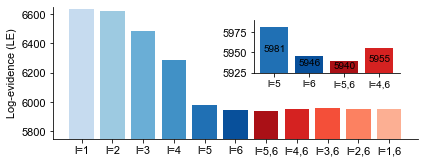

In [6]:
## Plot figure (fits + cv) ########################################################
plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')

path_save = sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_model_comparison'
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1,1,figsize=(8.3*2/num_panels+0.2,2.1)) # still need to set ratio differently (gridspec)

## Panel 1: Fits for single-distribution and two-distribution novelty
a_ll = ax.bar(np.arange(len(info_fitted)), 
              info_fitted['BIC'].values/2, 
              color=info_fitted['color'].values,
              alpha=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(len(info_fitted)))
ax.set_xticklabels(info_fitted['label'].values)

yl = 'Log-evidence (LE)'
ylim = [11500/2, 13300/2]
ax.set_ylabel(yl)
ax.set_ylim(ylim)

# Inset: zoom-in on best models
model_class_zoom = ['single','single','combined','combined']
model_level_zoom = [[5],[6],[5,6],[4,6]]
info_fitted_zoom = info_fitted.loc[(info_fitted['model_class'].isin(model_class_zoom)) & (info_fitted['level'].isin(model_level_zoom))]
ax_inset = ax.inset_axes([0.55, 0.5, 0.4, 0.4])
all_inset = ax_inset.bar(np.arange(len(info_fitted_zoom)), 
              info_fitted_zoom['BIC'].values/2, 
              color=info_fitted_zoom['color'].values,
              alpha=1)
ax_inset.bar_label(all_inset, fmt='%.f', label_type='center', rotation='horizontal', padding=1, fontsize=10)
ax_inset.spines[['top', 'right']].set_visible(False)
ax_inset.set_xticks(np.arange(len(info_fitted_zoom)))
ax_inset.set_xticklabels(info_fitted_zoom['label'].values, fontsize=10)
ax_inset.set_ylim([11850/2, 11980/2])

f.tight_layout(pad=0.1)
f.savefig(path_save / f'FIG3_E_logevidence_all-with-zoom.svg')

# Plot CV: winning models per class (Fig. 3 F)

In [7]:
## Specify models to plot #########################################################

model_type_list     = ['hnor','hnor','multinov-eps_hnor','multinov-eps_hnor']
model_label_list    = ['Counts\n', 'Counts\n', 'Best combined\n', 'Best combined\n']
level_label_list    = ['l=6', 'l=6', 'l=5,6', 'l=5,6']
leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*4
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
level_list          = [[6], [6], [5,6], [5,6]]
single_run_id_list  = ['_2','_5', '_1','_3'] # '', '_1', '_2', ... to distinguish multiple single runs with different initial conditions
trans_list          = [1, 0.6, 1, 0.6]
comb_type           = 'app'
run_local           = True
kfold               = 5
seed_list           = [42957]
version             = 4
scale_to_full       = True # if True, scale LL per step by total number of steps (n_app) to get comparable LL values
best_across_inits   = True # if True, take best LL across different initial conditions for each model
 
# Specify plotting parameters ######################################################

vmax   = 6
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b)
cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)
smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r)
color_list = [smap_b.to_rgba(vmax-1), smap_r.to_rgba(vmax-1)]

# Set paths to data files ##########################################################

base_path      = sl.get_rootpath()
base_path_data = sl.get_rootpath() / 'data' / 'mle_results' / 'fits_single-run' 
base_path_cv   = sl.get_rootpath() / 'data' / 'mle_results' / 'fits_cv-mouseid'

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/1683787741.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/1683787741.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)


In [8]:
# Extract cross-validated LL for all models #######################################

LL_train    = []
LL_test     = []
LL_fitted   = []
BIC_train   = []
BIC_test    = []
BIC_fitted  = []
LL_train_per_step = []
LL_test_per_step  = []
eps_train   = []
alph_train  = []
eps_fitted  = []
alph_fitted = []
num_params  = []
res_train   = []
res_test    = []
res_fitted  = []
# Load train / test / fitted LL for all models
for i, (model_type, leakiness_type, kernel_type, level, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, level_list, single_run_id_list)):

    if level is not None and kernel_type is not None:
        level_str   = '-'.join([str(lv) for lv in level]) if isinstance(level, list) else str(level)
        folder_load = f'{leakiness_type}_{model_type}_{kernel_type}/{leakiness_type}_{model_type}_{kernel_type}-l{level_str}-{comb_type}{sr_id}'
        full_model = f'{model_label_list[i]} ({level_label_list[i]})' 
    else:
        folder_load = f'{leakiness_type}_{model_type}'
        full_model = f'{leakiness_type}_{model_type}'

    # Load test and train data for each model (CV)
    res_train_i     = []
    res_test_i      = []
    eps_train_i     = []
    alph_train_i    = []
    
    cvid_all = 0
    for j, seed in enumerate(seed_list):

        # Load train / test CV files
        res_train_ij = pd.read_csv(base_path_cv / folder_load / f'results_train_app_{kfold}-fold_seed-{seed}.csv')
        res_test_ij  = pd.read_csv(base_path_cv / folder_load / f'results_test_app_{kfold}-fold_seed-{seed}.csv')

        for cvid in res_train_ij['cvID'].unique():
            res_train_ij.loc[res_train_ij['cvID'] == cvid, 'cvID'] = cvid_all
            res_test_ij.loc[res_test_ij['cvID'] == cvid, 'cvID']   = cvid_all
            cvid_all += 1

        res_train_i.append(res_train_ij)
        res_test_i.append(res_test_ij)

    res_train_i = pd.concat(res_train_i, ignore_index=True)
    res_test_i  = pd.concat(res_test_i, ignore_index=True)
    res_train_i['model_id']    = i
    res_train_i['model_class'] = full_model
    res_train_i['sr_id'] = sr_id
    res_test_i['model_id']     = i
    res_test_i['model_class']  = full_model
    res_test_i['sr_id'] = sr_id

    # Extract number of parameters
    num_params_i = len(res_train_i.var_name.unique())
    num_params.append(num_params_i)

    # Load split info and extract number of time steps for train / test
    split_info_j = pd.read_csv(base_path_cv / folder_load / f'info-splits_app_{kfold}-fold_seed-{seed_list[0]}.csv')
    n_sep_df = pd.DataFrame.from_dict(n_sep, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
    split_info_j = split_info_j.merge(n_sep_df, on='mouse_name', how='left')

    # Compute LL per timestep for train and test data
    len_train_i = [split_info_j.loc[(split_info_j['train_set']==True) & (split_info_j['set_id']==sid),'len'].sum() for sid in split_info_j['set_id'].unique()]
    len_test_i  = [split_info_j.loc[(split_info_j['test_set']==True) & (split_info_j['set_id']==sid),'len'].sum() for sid in split_info_j['set_id'].unique()]

    for sid, ltr, lte in zip(split_info_j['set_id'].unique(), len_train_i, len_test_i):
        res_train_i.loc[res_train_i['cvID']==sid,'len_train'] = ltr
        res_test_i.loc[res_test_i['cvID']==sid,'len_test']    = lte
    res_train_i['ll_per_step'] = res_train_i['mle_ll']/res_train_i['len_train']
    res_test_i['LL_per_step']  = res_test_i['LL']/res_test_i['len_test']

    LL_train_per_step_i = [res_train_i.loc[res_train_i['cvID']==cvid,'ll_per_step'].values[0] for cvid in res_train_i['cvID'].unique()]
    LL_test_per_step_i  = [res_test_i.loc[res_test_i['cvID']==cvid,'LL_per_step'].values[0] for cvid in res_test_i['cvID'].unique()]
    LL_train_per_step.append(LL_train_per_step_i)
    LL_test_per_step.append(LL_test_per_step_i)

    # Extract LL / BIC
    LL_train_i = [res_train_i.loc[res_train_i['cvID']==cvid,'mle_ll'].values[0] for cvid in res_train_i['cvID'].unique()]
    LL_test_i  = [res_test_i.loc[res_test_i['cvID']==cvid,'LL'].values[0] for cvid in res_test_i['cvID'].unique()]
    BIC_train_i = [2*ll + num_params_i * np.log(lt) for ll, lt in zip(LL_train_i, len_train_i)]
    BIC_test_i  = [2*ll + num_params_i * np.log(lt) for ll, lt in zip(LL_test_i, len_test_i)]
    
    # Extract fitted parameters
    if 'multinov-eps' in model_type:
        eps1_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak1'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
        eps2_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak2'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
        eps_train_i = [(e1, e2) for e1, e2 in zip(eps1_train_i, eps2_train_i)]
    else:
        eps_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
    alph_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='alph_leak'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]

    LL_train.append(LL_train_i)
    LL_test.append(LL_test_i)
    BIC_train.append(BIC_train_i)
    BIC_test.append(BIC_test_i)
    eps_train.append(eps_train_i)
    alph_train.append(alph_train_i)
    res_train.append(res_train_i)
    res_test.append(res_test_i)

    # Load fitted model 
    full_name   = f'mle_{leakiness_type}_{model_type}_{kernel_type}{sr_id}'
    fitted_path = base_path_data / full_name / f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}'
    fitted_file = f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}_{comb_type}.csv'
    fitted_params = sl.load_sim_data(fitted_path,file_data=fitted_file)  

    # Extract LL / BIC 
    LL_fitted.append(fitted_params['mle_ll'].values[0])
    BIC_fitted.append(2*fitted_params['mle_ll'].values[0] + num_params_i * np.log(n_app))
    res_fitted_i = pd.DataFrame({'model_id': i, 
                                'model_class': full_model,
                                'sr_id': sr_id,
                                'mle_ll': fitted_params['mle_ll'].values[0],
                                'len': n_app,
                                'll_per_step': fitted_params['mle_ll'].values[0] / n_app}, index=[0])
    res_fitted.append(res_fitted_i)

    # Extract fitted parameters
    if 'multinov-eps' in model_type:
        eps1_fitted = fitted_params.loc[fitted_params['var_name']=='eps_leak1','mle_var'].values[0]
        eps2_fitted = fitted_params.loc[fitted_params['var_name']=='eps_leak2','mle_var'].values[0]
        eps_fitted.append((eps1_fitted, eps2_fitted))
    else:
        eps_fitted.append(fitted_params.loc[fitted_params['var_name']=='eps_leak','mle_var'].values[0])
    alph_fitted.append(fitted_params.loc[fitted_params['var_name']=='alph_leak','mle_var'].values[0])

LL_train = np.array(LL_train) # num_models x kfold
LL_test = np.array(LL_test) # num_models x kfold
LL_train_per_step = np.array(LL_train_per_step)
LL_test_per_step = np.array(LL_test_per_step)
LL_fitted = np.array(LL_fitted)
BIC_train = np.array(BIC_train)
BIC_test = np.array(BIC_test)
BIC_fitted = np.array(BIC_fitted)
res_train = pd.concat(res_train, ignore_index=True)
res_test = pd.concat(res_test, ignore_index=True)
res_fitted = pd.concat(res_fitted, ignore_index=True)

cvID                              0           1            2            3  \
model_class                                                                 
Counts\n (l=6)           954.187254  394.567921  2821.279382  1375.120047   
Best combined\n (l=5,6)  956.193985  396.607041  2809.546019  1370.502470   

cvID                              4  
model_class                          
Counts\n (l=6)           386.333634  
Best combined\n (l=5,6)  383.455700  


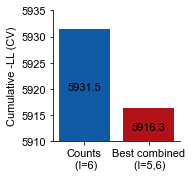

In [9]:
# Create plot #############################################################################

# Get best per model class across different initial conditions
if best_across_inits:
    res_best_train = res_train.groupby(['model_class', 'cvID']).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index() 
    res_best_test = res_test.groupby(['model_class', 'cvID']).apply(lambda x: x.loc[x['LL_per_step'].idxmin(), ['LL', 'LL_per_step', 'sr_id']]).reset_index() 
    res_best_fitted = res_fitted.groupby(['model_class']).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index()

else:
    # Plotting parameters
    models_with_colors      = pd.DataFrame({'model': full_models_list, 'color': color_list}).drop_duplicates()
    unique_model_types      = models_with_colors['model'].to_list() 
    unique_model_colors     = models_with_colors['color'].to_list()
    color_list_with_alphas  = list(zip(color_list, trans_list))

if best_across_inits:
    color_list_with_alphas = np.unique(color_list)

# Figure 1: Plot LL + LL differences (per step)
plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')

path_save = sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_model_comparison'
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1, 1, figsize=(8.3/num_panels-0.3, 2.3))

piv_res_best_train = res_best_train.pivot(index='model_class', columns='cvID', values='mle_ll')
piv_res_best_test  = res_best_test.pivot(index='model_class', columns='cvID', values='LL')
piv_res_best_train = piv_res_best_train.sort_index(ascending=False)
piv_res_best_test  = piv_res_best_test.sort_index(ascending=False)
print(piv_res_best_test)

# Lower row: Differences to best model
sum_LL_train = np.sum(piv_res_best_train.values, axis=1) # difference to best model per fold
sum_LL_test  = np.sum(piv_res_best_test.values, axis=1)  # difference to best model per fold
sum_LL_fitted = np.sum(res_best_fitted['mle_ll'].values)

y1 = sum_LL_train
y2 = sum_LL_test
y3 = sum_LL_fitted

fmt_bars = '%.1f' if scale_to_full else '%.e'

bb2 = ax.bar(np.arange(len(y2)), y2, color=color_list)
ax.bar_label(bb2, label_type='center', rotation='horizontal', fmt=fmt_bars, padding=-2)

ax.spines[['top','right']].set_visible(False)
ax.set_xticks(np.arange(len(piv_res_best_train.reset_index().model_class.unique())))
ax.set_xticklabels(piv_res_best_train.reset_index().model_class.unique())
ax.set_ylabel(f'Cumulative -LL (CV)')
ax.set_ylim([5910, 5935])

f.tight_layout(pad=0.1)
f.savefig(path_save / f'FIG3_F_cv-best.svg')

# Plot CV: all models (Fig. S5 A)

In [10]:
## Specify models to plot #########################################################

# Single level
model_type_list     = ['hnor']*12 # 12
model_label_list    = ['']*12
level_list          = [[1],[2],[3],[4],[5],[6]] + [[1],[2],[3],[4],[5],[6]]
level_label_list    = [f'l={ii[0]}' for ii in level_list]
single_run_id_list  = ['_1','_1','_4','_1','_1','_2'] + ['_5']*6

# Multiple level
model_type_list     += ['multinov-eps_hnor']*10
model_label_list    += ['']*10
new_level           = [[1,6],[2,6],[3,6],[4,6],[5,6]][::-1] + [[1,6],[2,6],[3,6],[4,6],[5,6]][::-1]
level_list          += new_level
level_label_list    += [f'l={",".join(map(str, ii))}' for ii in new_level]
single_run_id_list  += ['_2','_2','_2','_1','_1'][::-1] + ['_3']*5

leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
comb_type           = 'app'
run_local           = True
seed_list           = [42957]

# CV parameters
kfold               = 10
scale_to_full       = True # if True, scale LL per step by total number of steps (n_app) to get comparable LL values
best_across_inits   = True # if True, take best LL across different initial conditions for each model
 
## Specify plotting parameters ####################################################
extra  = 2
cnorm_b  = colors.Normalize(vmin=0, vmax=6+extra) 
cmap_b = plt.cm.get_cmap('Blues') 
smap_b = cm.ScalarMappable(norm=cnorm_b, cmap=cmap_b) # blue (single distribution)
cnorm_r  = colors.Normalize(vmin=0, vmax=5+extra)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm_r, cmap=cmap_r) # red (two-distribution nov.)

color_list  = [smap_b.to_rgba(ll) if len(ll)==1 else smap_r.to_rgba(ll[0]) for ll in level_list] 

model_class_list    = ['single' if not isinstance(ll, list) else 'combined' for ll in level_list]
trans_list          = [1]*len(color_list)

## Set paths to data files ########################################################
base_path       = sl.get_rootpath()
base_path_data = sl.get_rootpath() / 'data' / 'mle_results' / 'fits_single-run'
base_path_cv   = sl.get_rootpath() / 'data' / 'mle_results' / 'fits_cv-mouseid'


## Load fitting results for all models ############################################
LL_train    = []
LL_test     = []
LL_fitted   = []
BIC_train   = []
BIC_test    = []
BIC_fitted  = []
LL_train_per_step = []
LL_test_per_step  = []
eps_train   = []
alph_train  = []
eps_fitted  = []
alph_fitted = []
num_params  = []
res_train   = []
res_test    = []
res_fitted  = []

# Load train / test / fitted LL for all models
for i, (model_type, leakiness_type, kernel_type, level, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, level_list, single_run_id_list)):

    if level is not None and kernel_type is not None:
        level_str   = '-'.join([str(lv) for lv in level]) if isinstance(level, list) else str(level)
        folder_load = f'{leakiness_type}_{model_type}_{kernel_type}/{leakiness_type}_{model_type}_{kernel_type}-l{level_str}-{comb_type}{sr_id}'
        full_model = f'{model_label_list[i]}{level_label_list[i]}'
    else:
        folder_load = f'{leakiness_type}_{model_type}'
        full_model = f'{leakiness_type}_{model_type}'

    # Load test and train data for each model (CV)
    res_train_i     = []
    res_test_i      = []
    eps_train_i     = []
    alph_train_i    = []
    
    cvid_all = 0
    for j, seed in enumerate(seed_list):

        # Load train / test CV files
        res_train_ij = pd.read_csv(base_path_cv / folder_load / f'results_train_app_{kfold}-fold_seed-{seed}.csv')
        res_test_ij  = pd.read_csv(base_path_cv / folder_load / f'results_test_app_{kfold}-fold_seed-{seed}.csv')
        for cvid in res_train_ij['cvID'].unique():
            res_train_ij.loc[res_train_ij['cvID'] == cvid, 'cvID'] = cvid_all
            res_test_ij.loc[res_test_ij['cvID'] == cvid, 'cvID']   = cvid_all
            cvid_all += 1
        res_train_i.append(res_train_ij)
        res_test_i.append(res_test_ij)
    res_train_i = pd.concat(res_train_i, ignore_index=True)
    res_test_i  = pd.concat(res_test_i, ignore_index=True)
    res_train_i['model_id']    = i
    res_train_i['model_class'] = full_model
    res_train_i['sr_id'] = sr_id
    res_test_i['model_id']     = i
    res_test_i['model_class']  = full_model
    res_test_i['sr_id'] = sr_id

    # Extract number of parameters
    num_params_i = len(res_train_i.var_name.unique())
    num_params.append(num_params_i)

    # Load split info and extract number of time steps for train / test
    split_info_j = pd.read_csv(base_path_cv / folder_load / f'info-splits_app_{kfold}-fold_seed-{seed_list[0]}.csv')
    n_sep_df = pd.DataFrame.from_dict(n_sep, orient='index', columns=['len']).reset_index().rename(columns={'index':'mouse_name'})
    split_info_j = split_info_j.merge(n_sep_df, on='mouse_name', how='left')

    # Compute LL per timestep for train and test data
    len_train_i = [split_info_j.loc[(split_info_j['train_set']==True) & (split_info_j['set_id']==sid),'len'].sum() for sid in split_info_j['set_id'].unique()]
    len_test_i  = [split_info_j.loc[(split_info_j['test_set']==True) & (split_info_j['set_id']==sid),'len'].sum() for sid in split_info_j['set_id'].unique()]

    for sid, ltr, lte in zip(split_info_j['set_id'].unique(), len_train_i, len_test_i):
        res_train_i.loc[res_train_i['cvID']==sid,'len_train'] = ltr
        res_test_i.loc[res_test_i['cvID']==sid,'len_test']    = lte
    res_train_i['ll_per_step'] = res_train_i['mle_ll']/res_train_i['len_train']
    res_test_i['LL_per_step']  = res_test_i['LL']/res_test_i['len_test']

    LL_train_per_step_i = [res_train_i.loc[res_train_i['cvID']==cvid,'ll_per_step'].values[0] for cvid in res_train_i['cvID'].unique()]
    LL_test_per_step_i  = [res_test_i.loc[res_test_i['cvID']==cvid,'LL_per_step'].values[0] for cvid in res_test_i['cvID'].unique()]
    LL_train_per_step.append(LL_train_per_step_i)
    LL_test_per_step.append(LL_test_per_step_i)

    # Extract LL / BIC
    LL_train_i = [res_train_i.loc[res_train_i['cvID']==cvid,'mle_ll'].values[0] for cvid in res_train_i['cvID'].unique()]
    LL_test_i  = [res_test_i.loc[res_test_i['cvID']==cvid,'LL'].values[0] for cvid in res_test_i['cvID'].unique()]
    BIC_train_i = [2*ll + num_params_i * np.log(lt) for ll, lt in zip(LL_train_i, len_train_i)]
    BIC_test_i  = [2*ll + num_params_i * np.log(lt) for ll, lt in zip(LL_test_i, len_test_i)]
    
    # Extract fitted parameters
    if 'multinov-eps' in model_type:
        eps1_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak1'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
        eps2_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak2'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
        eps_train_i = [(e1, e2) for e1, e2 in zip(eps1_train_i, eps2_train_i)]
    else:
        eps_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='eps_leak'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]
    alph_train_i = [res_train_i.loc[(res_train_i['cvID']==cvid) & (res_train_i['var_name']=='alph_leak'),'mle_var'].values[0] for cvid in res_train_i['cvID'].unique()]

    LL_train.append(LL_train_i)
    LL_test.append(LL_test_i)
    BIC_train.append(BIC_train_i)
    BIC_test.append(BIC_test_i)
    eps_train.append(eps_train_i)
    alph_train.append(alph_train_i)
    res_train.append(res_train_i)
    res_test.append(res_test_i)

    # Load fitted model 
    full_name   = f'mle_{leakiness_type}_{model_type}_{kernel_type}{sr_id}'
    fitted_path = base_path_data / full_name / f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}'
    fitted_file = f'mle_{leakiness_type}_{model_type}_{kernel_type}-l{level_str}_{comb_type}.csv'
    fitted_params = sl.load_sim_data(fitted_path,file_data=fitted_file)  

    # Extract LL / BIC 
    LL_fitted.append(fitted_params['mle_ll'].values[0])
    BIC_fitted.append(2*fitted_params['mle_ll'].values[0] + num_params_i * np.log(n_app))
    res_fitted_i = pd.DataFrame({'model_id': i, 
                                'model_class': full_model,
                                'sr_id': sr_id,
                                'mle_ll': fitted_params['mle_ll'].values[0],
                                'len': n_app,
                                'll_per_step': fitted_params['mle_ll'].values[0] / n_app}, index=[0])
    res_fitted.append(res_fitted_i)

    # Extract fitted parameters
    if 'multinov-eps' in model_type:
        eps1_fitted = fitted_params.loc[fitted_params['var_name']=='eps_leak1','mle_var'].values[0]
        eps2_fitted = fitted_params.loc[fitted_params['var_name']=='eps_leak2','mle_var'].values[0]
        eps_fitted.append((eps1_fitted, eps2_fitted))
    else:
        eps_fitted.append(fitted_params.loc[fitted_params['var_name']=='eps_leak','mle_var'].values[0])
    alph_fitted.append(fitted_params.loc[fitted_params['var_name']=='alph_leak','mle_var'].values[0])

LL_train = np.array(LL_train) # num_models x kfold
LL_test = np.array(LL_test) # num_models x kfold
LL_train_per_step = np.array(LL_train_per_step)
LL_test_per_step = np.array(LL_test_per_step)
LL_fitted = np.array(LL_fitted)
BIC_train = np.array(BIC_train)
BIC_test = np.array(BIC_test)
BIC_fitted = np.array(BIC_fitted)
res_train = pd.concat(res_train, ignore_index=True)
res_test = pd.concat(res_test, ignore_index=True)
res_fitted = pd.concat(res_fitted, ignore_index=True)


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/588594728.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/588594728.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')


cvID                  0           1          2           3            4  \
model_class                                                               
l=1          947.553434  103.542879  47.833633  384.511593  1100.923246   
l=2          942.909721  104.361745  47.804013  386.182923  1093.397270   
l=3          921.931393  103.900265  47.789228  378.985596  1070.865862   
l=4          892.813668  104.659142  48.318148  371.006190  1018.255828   
l=5          866.164316  103.995149  48.660093  350.385751   985.899818   
l=6          852.619502  101.613120  49.673969  345.502465   974.489473   
l=5,6        853.697100  102.927862  49.081771  346.940366   974.702724   
l=4,6        855.957104  101.616439  49.716924  345.640917   975.218027   
l=3,6        852.756103  101.465651  49.714805  345.373494   974.762357   
l=2,6        852.789256  100.670370  49.679571  345.767671   975.627163   
l=1,6        852.587564  101.406964  49.673451  345.358238   975.189492   

cvID                   5

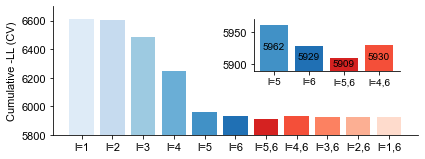

In [11]:
# Get best per model class across different initial conditions
if best_across_inits:
    
    res_best_train = res_train.groupby(['model_class', 'cvID'], sort=False).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index() 
    res_best_test = res_test.groupby(['model_class', 'cvID'], sort=False).apply(lambda x: x.loc[x['LL_per_step'].idxmin(), ['LL', 'LL_per_step', 'sr_id']]).reset_index() 
    res_best_fitted = res_fitted.groupby(['model_class'], sort=False).apply(lambda x: x.loc[x['ll_per_step'].idxmin(), ['mle_ll', 'll_per_step', 'sr_id']]).reset_index()

else:
    # Plotting parameters
    models_with_colors      = pd.DataFrame({'model': full_models_list, 'color': color_list}).drop_duplicates()
    unique_model_types      = models_with_colors['model'].to_list() 
    unique_model_colors     = models_with_colors['color'].to_list()
    color_list_with_alphas  = list(zip(color_list, trans_list))

# if best_across_inits:
#     color_list_with_alphas = np.unique(color_list)

# Figure 1: Plot LL + LL differences (per step)
plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')

path_save = sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_model_comparison'
sl.make_long_dir(path_save)

num_panels = 3
f, ax = plt.subplots(1, 1, figsize=(8.3*2/num_panels+0.2, 2.05))

res_best_train.model_class = pd.Categorical(res_best_train.model_class, categories=res_best_train.model_class.unique(), ordered=True)
res_best_test.model_class = pd.Categorical(res_best_test.model_class, categories=res_best_test.model_class.unique(), ordered=True)
piv_res_best_train = res_best_train.pivot(index='model_class', columns='cvID', values='mle_ll')
piv_res_best_test  = res_best_test.pivot(index='model_class', columns='cvID', values='LL')
print(piv_res_best_test)

# Set colors
piv_res_best_test2  = piv_res_best_test.reset_index()
plot_level_list     = [int(ll.split('l=')[-1].split(')')[0].split(',')[0]) for ll in piv_res_best_test2['model_class'].values] 
color_list          = [smap_r.to_rgba(ll) if ',' in ll_name else smap_b.to_rgba(ll) for ll, ll_name in zip(plot_level_list, piv_res_best_test2['model_class'])] 
piv_res_best_test2['level'] = plot_level_list
piv_res_best_test2['color'] = color_list

# Set what to plot row: best per fold
sum_LL_train = np.sum(piv_res_best_train.values, axis=1) 
sum_LL_test  = np.sum(piv_res_best_test.values, axis=1)  
sum_LL_fitted = np.sum(res_best_fitted['mle_ll'].values)
piv_res_best_test2['sum_LL_test'] = sum_LL_test

y1 = sum_LL_train
y2 = sum_LL_test
y3 = sum_LL_fitted

# Plot CV-LL
bb2 = ax.bar(np.arange(len(y2)), y2, color=color_list)
ax.spines[['top','right']].set_visible(False)
ax.set_xticks(np.arange(len(piv_res_best_train.reset_index().model_class.unique())))
ax.set_xticklabels(piv_res_best_train.reset_index().model_class.unique())
ax.set_ylabel(f'Cumulative -LL (CV)')
ax.set_ylim([5800, 6700])

# Zoomed inset
model_class_zoom = ['l=5','l=6','l=5,6','l=4,6']
piv_res_best_test_zoom = piv_res_best_test2.loc[piv_res_best_test2['model_class'].isin(model_class_zoom)]
ax_inset  = ax.inset_axes([0.55, 0.5, 0.4, 0.4])
all_inset = ax_inset.bar(np.arange(len(piv_res_best_test_zoom)), 
                            piv_res_best_test_zoom['sum_LL_test'].values,
                            color=piv_res_best_test_zoom['color'].values,
                            alpha=1)
ax_inset.bar_label(all_inset, fmt='%.f', label_type='center', rotation='horizontal', padding=1, fontsize=10)
ax_inset.spines[['top', 'right']].set_visible(False)
ax_inset.set_xticks(np.arange(len(info_fitted_zoom)))
ax_inset.set_xticklabels(info_fitted_zoom['label'].values, fontsize=10)
ax_inset.set_ylim([5890, 5970])

# Save figure
f.tight_layout(pad=0.1)
f.savefig(path_save / f'FIG_S5_cv-all.svg')

# Print parameter values 

In [12]:
## Specify models to plot #########################################################

# Single level
model_type_list     = ['hnor']
model_label_list    = ['Single\n']
level_list          = [[[1],[2],[3],[4],[5],[6]]]
level_label_list    = [[f'l={ii[0]}' for ii in level_list[0]]]
single_run_id_list  = ['_5']

# Multiple level
model_type_list     += ['multinov-eps_hnor']
model_label_list    += ['Combined\n']
level_list          += [[[1,6],[2,6],[3,6],[4,6],[5,6]][::-1]]
level_label_list    += [[f'l={",".join(map(str, ii))}' for ii in level_list[1]]]
single_run_id_list  += ['_3']

leakiness_type_list = ['leaky']*len(model_type_list)
kernel_type_list    = ['notrace']*len(model_type_list)
full_models_list    = [f'{lt}_{mt}_{kt}' if kt is not None else f'{lt}_{mt}' for lt, mt, kt in zip(leakiness_type_list, model_type_list, kernel_type_list)]
comb_type           = 'app'
run_local           = True
seed_list           = [42957]
version             = 4

## Specify plotting parameters ####################################################
extra  = 2
cnorm_b  = colors.Normalize(vmin=0, vmax=len(level_list[0])+extra) 
cmap_b = plt.cm.get_cmap('Blues') 
smap_b = cm.ScalarMappable(norm=cnorm_b, cmap=cmap_b) # blue (single distribution)
cnorm_r  = colors.Normalize(vmin=0, vmax=len(level_list[1])+extra)
cmap_r = plt.cm.get_cmap('Reds')
smap_r = cm.ScalarMappable(norm=cnorm_r, cmap=cmap_r) # red (two-distribution nov.)

color_list  = [[smap_b.to_rgba(i) for i in range(extra,extra+len(level_list[0]))]]
color_list += [[smap_r.to_rgba(i) for i in range(extra,extra+len(level_list[1]))][::-1]]

model_class_list    = [['single']*len(color_list[0]), ['combined']*len(color_list[1])] 
trans_list          = [[1]*len(color_list[0]), [1]*len(color_list[1])]

## Set paths to data files ########################################################
base_path       = sl.get_rootpath()
base_path_data  = base_path / 'data' / 'mle_results' / f'fits_single-run'
base_path_cv  = base_path / 'data' / 'mle_results' / f'fits_cross-validation_mouseid'

## Load fitting results for all models ############################################
info_param_fitted = []
for i, (model_type, leak_type, kernel_type, full_model, levels, sr_id) in enumerate(zip(model_type_list, leakiness_type_list, kernel_type_list, full_models_list, level_list, single_run_id_list)):

    LL_fitted_i  = []
    PP_fitted_i  = []
    BIC_fitted_i = []
    num_params_i = []
    labels_i     = []
    alph_leak_i  = []
    k_leak_i     = []
    for j, level_j in enumerate(levels):

        if level_j is not None and kernel_type is not None:
            level_str   = '-'.join([str(lv) for lv in level_j]) if isinstance(level_j, list) else str(level_j)
        
        # Construct path to fitted model 
        full_name   = f'mle_{leak_type}_{model_type}_{kernel_type}{sr_id}'
        fitted_path = base_path_data / full_name / f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}'
        fitted_file = f'mle_{leak_type}_{model_type}_{kernel_type}-l{level_str}_{comb_type}.csv'
        
        # Load fitted model
        fitted_ij = sl.load_sim_data(fitted_path,file_data=fitted_file)

        # Extract LL / BIC 
        num_params_ij = len(fitted_ij.var_name.unique())
        penalty_ij    = num_params_ij * np.log(n_app)
        num_params_i.append(num_params_ij)
        LL_fitted_i.append(fitted_ij['mle_ll'].values[0])
        PP_fitted_i.append(penalty_ij)
        BIC_fitted_i.append(2*fitted_ij['mle_ll'].values[0] + penalty_ij)
        alph_leak_i.append(fitted_ij.loc[fitted_ij['var_name']=='alph_leak','mle_var'].values[0])
        k_leak_i.append(fitted_ij.loc[fitted_ij['var_name']=='k_leak','mle_var'].values[0])

        # Create label
        if level_j is not None:
            label_ij = level_label_list[i][j]
            labels_i.append(label_ij)
        else:
            labels_i.append(model_label_list[i])

    print(len(LL_fitted_i), len(model_class_list[i]), len(color_list[i]), len(trans_list[i]))
    info_param_fitted_i = pd.DataFrame({'full_model': [full_model]*len(LL_fitted_i),
                                    'model_class': model_class_list[i][:len(LL_fitted_i)+1],
                                    'model_id': [i]*len(LL_fitted_i),
                                    'level': levels,
                                    'LL': LL_fitted_i,
                                    'PP': PP_fitted_i,
                                    'BIC': BIC_fitted_i,
                                    'alph_leak': alph_leak_i,
                                    'k_leak': k_leak_i,
                                    'color': color_list[i][:len(LL_fitted_i)+1],
                                    'trans': trans_list[i][:len(LL_fitted_i)+1],
                                    'label': labels_i})
    info_param_fitted.append(info_param_fitted_i)

info_param_fitted = pd.concat(info_param_fitted)

6 6 6 6
5 5 5 5


/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/873224290.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues')
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/873224290.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')


In [13]:
info_param_fitted

,full_model,model_class,model_id,level,LL,PP,BIC,alph_leak,k_leak,color,trans,label
0,leaky_hnor_notrace,single,0,[1],6609.121823,53.902144,13272.145791,0.346966,9.999649e-01,"(0.7752402921953095, 0.8583006535947711, 0.936...",1,l=1
1,leaky_hnor_notrace,single,0,[2],6595.787990,53.902144,13245.478124,0.177278,9.999998e-01,"(0.6172549019607844, 0.7908650519031142, 0.881...",1,l=2
2,leaky_hnor_notrace,single,0,[3],6459.273146,53.902144,12972.448435,0.209975,4.294247e-16,"(0.41708573625528644, 0.6806305267204922, 0.83...",1,l=3
3,leaky_hnor_notrace,single,0,[4],6260.690691,53.902144,12575.283527,0.167834,3.042535e-06,"(0.25628604382929643, 0.5700115340253749, 0.77...",1,l=4
4,leaky_hnor_notrace,single,0,[5],5953.809488,53.902144,11961.521120,0.232311,7.384733e-02,"(0.1271049596309112, 0.4401845444059977, 0.707...",1,l=5
5,leaky_hnor_notrace,single,0,[6],5918.580678,53.902144,11891.063500,0.576867,9.999647e-01,"(0.03137254901960784, 0.3140945790080738, 0.60...",1,l=6
0,leaky_multinov-eps_hnor_notrace,combined,1,"[5, 6]",5903.814200,71.869525,11879.497925,0.502825,6.633791e-01,"(0.6663437139561708, 0.06339100346020761, 0.08...",1,"l=5,6"
1,leaky_multinov-eps_hnor_notrace,combined,1,"[4, 6]",5919.332664,71.869525,11910.534854,0.500319,1.429807e-01,"(0.8370472895040368, 0.13394848135332565, 0.13...",1,"l=4,6"
2,leaky_multinov-eps_hnor_notrace,combined,1,"[3, 6]",5920.483582,71.869525,11912.836690,0.499596,3.621834e-01,"(0.9570011534025374, 0.3087120338331411, 0.221...",1,"l=3,6"
3,leaky_multinov-eps_hnor_notrace,combined,1,"[2, 6]",5919.121956,71.869525,11910.113438,0.507544,4.970034e-01,"(0.9865897731641676, 0.5067281814686659, 0.381...",1,"l=2,6"


Best count-based : alph_leak = 0.576867

Best similarity-based: alph_leak = 0.502825

In [14]:
half_life = np.log(1/2) / np.log(1-info_param_fitted['alph_leak'].values)
info_param_fitted['half_life'] = half_life

info_param_fitted

,full_model,model_class,model_id,level,LL,PP,BIC,alph_leak,k_leak,color,trans,label,half_life
0,leaky_hnor_notrace,single,0,[1],6609.121823,53.902144,13272.145791,0.346966,9.999649e-01,"(0.7752402921953095, 0.8583006535947711, 0.936...",1,l=1,1.626623
1,leaky_hnor_notrace,single,0,[2],6595.787990,53.902144,13245.478124,0.177278,9.999998e-01,"(0.6172549019607844, 0.7908650519031142, 0.881...",1,l=2,3.552117
2,leaky_hnor_notrace,single,0,[3],6459.273146,53.902144,12972.448435,0.209975,4.294247e-16,"(0.41708573625528644, 0.6806305267204922, 0.83...",1,l=3,2.940919
3,leaky_hnor_notrace,single,0,[4],6260.690691,53.902144,12575.283527,0.167834,3.042535e-06,"(0.25628604382929643, 0.5700115340253749, 0.77...",1,l=4,3.772774
4,leaky_hnor_notrace,single,0,[5],5953.809488,53.902144,11961.521120,0.232311,7.384733e-02,"(0.1271049596309112, 0.4401845444059977, 0.707...",1,l=5,2.621882
5,leaky_hnor_notrace,single,0,[6],5918.580678,53.902144,11891.063500,0.576867,9.999647e-01,"(0.03137254901960784, 0.3140945790080738, 0.60...",1,l=6,0.805921
0,leaky_multinov-eps_hnor_notrace,combined,1,"[5, 6]",5903.814200,71.869525,11879.497925,0.502825,6.633791e-01,"(0.6663437139561708, 0.06339100346020761, 0.08...",1,"l=5,6",0.991893
1,leaky_multinov-eps_hnor_notrace,combined,1,"[4, 6]",5919.332664,71.869525,11910.534854,0.500319,1.429807e-01,"(0.8370472895040368, 0.13394848135332565, 0.13...",1,"l=4,6",0.999080
2,leaky_multinov-eps_hnor_notrace,combined,1,"[3, 6]",5920.483582,71.869525,11912.836690,0.499596,3.621834e-01,"(0.9570011534025374, 0.3087120338331411, 0.221...",1,"l=3,6",1.001165
3,leaky_multinov-eps_hnor_notrace,combined,1,"[2, 6]",5919.121956,71.869525,11910.113438,0.507544,4.970034e-01,"(0.9865897731641676, 0.5067281814686659, 0.381...",1,"l=2,6",0.978539


This corresponds to half-life of about 1 observation. Worse fits are achieved for lower alph_leak values (i.e. higher half-lives).


# Plot winning model simulations

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/609269591.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_54724/609269591.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)


loading precomputed steps to goal for model 0
loading precomputed steps to goal for model 1
loading precomputed steps to goal for model 2


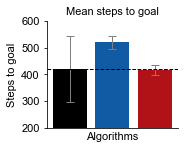

In [15]:
# Load style file
plt.style.use(sl.get_rootpath() / 'src' / 'utils' / 'paper.mplstyle')

# Folders for saving data and figures
path_data_save = sl.get_rootpath() / 'data' / 'ppc'
path_fig_save  = sl.get_rootpath() / 'output' / 'figures_paper' / 'fig_model_comparison'
sl.make_long_dir(path_data_save)
sl.make_long_dir(path_fig_save)

# Folders for loading data
path_exp    = sl.get_rootpath() / 'ext_data' / 'Rosenberg2021'
path_sim    = sl.get_rootpath() / 'data' / 'ppc' 

# Which plots to make
plot_newnor = True

# Plot first row (hybrid model)
if plot_newnor:
    plot_medians    = False
    lw              = 1
    plot_type   = 'comp_newnor'   # 'mice_only','comp_hyb2','comp_nor','comp_algs'
    no_rew      = False         # if true: include only unrewarded mice
    maxit       = 3000          # number of steps included (only relevant for node discovery plots)
    figsize     = (2.05,2.05)
    
    paths_load  = [path_exp, path_sim, path_sim]
    legendstr   = ['Mice','Single','Combined']
    savename    = ['mice_expl' if no_rew else 'mice_full','leaky_hnor_notrace_5_app_l6','leaky_multinov-eps_hnor_notrace_3_app_l5-6']
    vmax   = 6
    cnorm  = colors.Normalize(vmin=0, vmax=vmax)
    cmap_b = plt.cm.get_cmap('Blues') # blue (single-distribution)
    smap_b = cm.ScalarMappable(norm=cnorm, cmap=cmap_b)
    cmap_r = plt.cm.get_cmap('Reds')  # red (two-distribution)
    smap_r = cm.ScalarMappable(norm=cnorm, cmap=cmap_r)
    cols        = ['k',smap_b.to_rgba(vmax-1), smap_r.to_rgba(vmax-1)]

    f_mean,ax_mean = plt.subplots(1,1,figsize=(8.1/3,2.2))
    ax1 = [ax_mean]
    if plot_medians:
        f_med,ax_med = plt.subplots(1,1,figsize=(8.1/3,2.2))
        ax1.append(ax_med)

    # NOTE: to recompute the statistics from simulation data from scratch, set recomp=True -- here, we load precomputed data.
    plot_steps_to_goal_all(plot_type, path_data_save / 'steps_to_goal', path_fig_save, no_rew, paths_load, legendstr, savename, cols, plot_dp=False, recomp=False, cut_outlier=False, axl=ax1, lw=lw, plot_medians=plot_medians)
    
    ax_mean.set_ylim(200,600)
    ax_mean.spines[['top', 'right']].set_visible(False)
    ax_mean.set_ylabel('Steps to goal')
    ax_mean.set_yscale('linear')
    f_mean.tight_layout()
    f_mean.savefig(path_fig_save / f'FIG_S5_stg_mean.svg')

    if plot_medians:
        f_med.tight_layout()
        f_med.savefig(path_fig_save / f'FIG_S5_stg_median.svg')
